# Bridge Notebook 04 — EDA of UniProt Protein Descriptors with `modlamp`

## From the UniProt 300-protein descriptor table to exploratory analysis

This notebook continues the sequence-processing workflow from the previous notebook.

The previous notebook generated a UniProt-derived descriptor file:

```text
outputs/uniprot_proteins_300_descriptors.csv
```

In this notebook, that file is used as the **main input**. The goal is to build a simple exploratory data analysis workflow using protein physicochemical descriptors calculated with `modlamp`.

The workflow is:

```text
UniProt protein descriptor CSV
↓
protein sequence filtering
↓
modlamp descriptor calculation
↓
synthetic or existing Healthy/Diseased label
↓
simple EDA by label
↓
PCA visualization
↓
export processed tables
```

> **Important teaching note**  
> UniProt records describe proteins, not patient-level clinical samples. Therefore, if the input file does not contain a real biological or clinical label, this notebook creates a **synthetic educational label** called `Healthy` / `Diseased` and `Sano` / `Enfermo`. This label is only used to practice EDA and should not be interpreted as a real disease annotation.

## 0. Learning objectives

By the end of this notebook, students should be able to:

1. Load a CSV containing UniProt protein sequences and metadata.
2. Reuse a descriptor table generated in a previous notebook.
3. Validate and filter protein sequences.
4. Calculate physicochemical protein descriptors using `modlamp`.
5. Add or reuse a categorical label for group-wise exploration.
6. Perform simple EDA using summary tables and visualizations.
7. Run PCA on numerical descriptors.
8. Export an EDA-ready dataset for later notebooks.

## 1. Conceptual definitions

### Protein descriptor

A **protein descriptor** is a numerical value that summarizes a property of a protein sequence.

Examples include:

- sequence length
- molecular weight
- estimated charge
- isoelectric point
- hydrophobicity-related values
- aromaticity
- instability index

Descriptors convert protein sequences into a structured numerical table.

### Physicochemical property

A **physicochemical property** describes a physical or chemical characteristic of a protein sequence. These properties are estimated from amino acid composition and amino-acid-specific scales.

Examples include charge, hydrophobicity, aliphatic index and molecular weight.

### EDA

**Exploratory Data Analysis** is the first stage of data understanding. It helps answer questions such as:

- How many sequences do we have?
- Are there missing values?
- How are labels distributed?
- Which descriptors differ between groups?
- Do samples cluster in a low-dimensional projection?

### PCA

**Principal Component Analysis** is a dimensionality reduction method. It projects many numerical descriptors into a smaller number of new axes called principal components.

In this notebook, PCA is used only for visualization, not for classification.

## 2. Setup

This notebook uses `modlamp` for protein descriptor calculation.

If `modlamp` is not installed, run:

```python
%pip install modlamp
```

In [5]:
# Uncomment if needed.
# %pip install modlamp

In [6]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from modlamp.descriptors import GlobalDescriptor, PeptideDescriptor

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 3. Configuration

The preferred input is the descriptor file created in Notebook 03:

```text
outputs/uniprot_proteins_300_descriptors.csv
```

The other files are only fallback options for teaching/demo execution.

In [7]:
BASE_DIR = Path("../")
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

PREFERRED_INPUT = OUTPUT_DIR / "uniprot_proteins_300_descriptors.csv"

INPUT_CANDIDATES = [
    PREFERRED_INPUT,
    BASE_DIR / "uniprot_proteins_300_descriptors.csv",
    OUTPUT_DIR / "uniprot_proteins_300_metadata.csv",
    BASE_DIR / "uniprot_proteins_300_metadata.csv",
    OUTPUT_DIR / "combined_sequence_dataset.csv",
    BASE_DIR / "combined_sequence_dataset.csv",
]

# For classroom/demo execution only.
CREATE_SYNTHETIC_DEMO_IF_SMALL = True
MIN_PROTEIN_ROWS_FOR_EDA = 20
SYNTHETIC_DEMO_N = 100

# modlamp parameters
PH = 7.4
AMIDE = False
HYDROPHOBIC_MOMENT_WINDOW = 11
PROFILE_WINDOW = 11

# Output files
FEATURES_WITH_LABELS_CSV = OUTPUT_DIR / "uniprot300_modlamp_features_with_labels.csv"
DESCRIPTOR_MATRIX_CSV = OUTPUT_DIR / "uniprot300_modlamp_descriptor_matrix.csv"
PCA_COORDINATES_CSV = OUTPUT_DIR / "uniprot300_modlamp_pca_coordinates.csv"
PCA_LOADINGS_CSV = OUTPUT_DIR / "uniprot300_modlamp_pca_loadings.csv"
SUMMARY_BY_LABEL_CSV = OUTPUT_DIR / "uniprot300_modlamp_summary_by_label.csv"

## 4. Load the UniProt descriptor table

This section loads the CSV generated by Notebook 03.

The expected main input is:

```text
outputs/uniprot_proteins_300_descriptors.csv
```

In [8]:
def find_existing_file(candidates):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "No input CSV was found. Expected one of:\n" +
        "\n".join(str(p) for p in candidates)
    )

input_csv = find_existing_file(INPUT_CANDIDATES)
print(f"Selected input file: {input_csv}")

if input_csv.name != "uniprot_proteins_300_descriptors.csv":
    print("WARNING: The preferred file was not found. A fallback/demo file is being used.")
    print("For the real workflow, place uniprot_proteins_300_descriptors.csv inside the outputs/ directory.")

Selected input file: ../outputs/uniprot_proteins_300_descriptors.csv


In [9]:
raw_df = pd.read_csv(input_csv)
print(f"Shape: {raw_df.shape}")
raw_df.head()

Shape: (300, 63)


,sequence_id,organism,molecule_type,source,description,sequence,length,valid_protein_standard_20aa,unknown_or_nonstandard_fraction,estimated_molecular_weight_da,hydrophobic_fraction,aromatic_fraction,positive_fraction,negative_fraction,charged_fraction,polar_fraction,shannon_entropy,normalized_entropy,gini_impurity,simpson_concentration,max_residue_frequency,kmer_entropy_k2,kmer_entropy_k3,aa_A_count,aa_A_freq,aa_C_count,aa_C_freq,aa_D_count,aa_D_freq,aa_E_count,aa_E_freq,aa_F_count,aa_F_freq,aa_G_count,aa_G_freq,aa_H_count,aa_H_freq,aa_I_count,aa_I_freq,aa_K_count,aa_K_freq,aa_L_count,aa_L_freq,aa_M_count,aa_M_freq,aa_N_count,aa_N_freq,aa_P_count,aa_P_freq,aa_Q_count,aa_Q_freq,aa_R_count,aa_R_freq,aa_S_count,aa_S_freq,aa_T_count,aa_T_freq,aa_V_count,aa_V_freq,aa_W_count,aa_W_freq,aa_Y_count,aa_Y_freq
0,A0A0C5B5G6,Homo sapiens (Human),protein,UniProtKB,entry_name=MOTSC_HUMAN; protein_name=Mitochond...,MRWQEMGYIFYPRKLR,16,True,0.0,2174.61248,0.500000,0.250000,0.250000,0.062500,0.312500,0.187500,3.452820,0.798907,0.898438,0.101562,0.187500,3.906891,3.807355,0,0.000000,0,0.000000,0,0.000000,1,0.062500,1,0.062500,1,0.062500,0,0.000000,1,0.062500,1,0.062500,1,0.062500,2,0.125000,0,0.000000,1,0.062500,1,0.062500,3,0.187500,0,0.000000,0,0.000000,0,0.000000,1,0.062500,2,0.125000
1,A0A1B0GTW7,Homo sapiens (Human),protein,UniProtKB,entry_name=CIROP_HUMAN; protein_name=Ciliated ...,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788,True,0.0,85396.90478,0.369289,0.065990,0.121827,0.078680,0.200508,0.288071,4.064488,0.940434,0.930032,0.069968,0.143401,7.732478,9.347064,54,0.068528,29,0.036802,27,0.034264,35,0.044416,19,0.024112,71,0.090102,30,0.038071,17,0.021574,26,0.032995,113,0.143401,13,0.016497,14,0.017766,61,0.077411,40,0.050761,40,0.050761,76,0.096447,48,0.060914,42,0.053299,13,0.016497,20,0.025381
2,A0JNW5,Homo sapiens (Human),protein,UniProtKB,entry_name=BLT3B_HUMAN; protein_name=Bridge-li...,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,1464,True,0.0,164198.50728,0.353825,0.067623,0.138661,0.127049,0.265710,0.321038,4.131155,0.955859,0.936463,0.063537,0.120902,8.045432,10.183463,73,0.049863,25,0.017077,88,0.060109,98,0.066940,52,0.035519,55,0.037568,48,0.032787,84,0.057377,104,0.071038,145,0.099044,35,0.023907,78,0.053279,67,0.045765,70,0.047814,51,0.034836,177,0.120902,85,0.058060,82,0.056011,12,0.008197,35,0.023907
3,A0JP26,Homo sapiens (Human),protein,UniProtKB,entry_name=POTB3_HUMAN; protein_name=POTE anky...,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,581,True,0.0,65710.34248,0.313253,0.041308,0.177281,0.156627,0.333907,0.285714,4.121349,0.953590,0.936394,0.063606,0.104991,7.566341,8.816284,31,0.053356,22,0.037866,37,0.063683,54,0.092943,9,0.015491,33,0.056799,20,0.034423,21,0.036145,54,0.092943,61,0.104991,18,0.030981,35,0.060241,16,0.027539,30,0.051635,29,0.049914,47,0.080895,22,0.037866,27,0.046472,5,0.008606,10,0.017212
4,A0PK11,Homo sapiens (Human),protein,UniProtKB,entry_name=CLRN2_HUMAN; protein_name=Clarin-2;...,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232,True,0.0,25446.15678,0.560345,0.112069,0.090517,0.073276,0.163793,0.198276,4.031608,0.932826,0.927504,0.072496,0.133621,6.998361,7.717187,25,0.107759,5,0.021552,5,0.021552,12,0.051724,15,0.064655,17,0.073276,5,0.021552,19,0.081897,10,0.043103,31,0.133621,4,0.017241,6,0.025862,7,0.030172,9,0.038793,6,0.025862,13,0.056034,7,0.030172,25,0.107759,5,0.021552,6,0.025862


## 5. Detect important columns

Different databases may use slightly different names for the same concept. We detect the most likely columns for:

- sequence
- protein ID or accession
- organism
- molecule type
- description

In [10]:
def first_existing_column(df, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise ValueError(f"None of these columns were found: {candidates}")
    return None

sequence_col = first_existing_column(
    raw_df,
    ["sequence", "Sequence", "protein_sequence", "aa_sequence", "amino_acid_sequence"],
)

id_col = first_existing_column(
    raw_df,
    ["sequence_id", "uniprot_accession", "uniprot_id", "accession", "primaryAccession", "Entry", "id", "ID"],
    required=False,
)

organism_col = first_existing_column(
    raw_df,
    ["organism", "organism_name", "Organism", "scientific_name", "taxon", "species"],
    required=False,
)

molecule_col = first_existing_column(
    raw_df,
    ["molecule_type", "molecule", "type", "sequence_type"],
    required=False,
)

description_col = first_existing_column(
    raw_df,
    ["description", "protein_name", "Protein names", "proteinDescription", "name"],
    required=False,
)

print("Detected columns")
print("sequence_col:", sequence_col)
print("id_col:", id_col)
print("organism_col:", organism_col)
print("molecule_col:", molecule_col)
print("description_col:", description_col)

Detected columns
sequence_col: sequence
id_col: sequence_id
organism_col: organism
molecule_col: molecule_type
description_col: description


## 6. Keep standard protein sequences

For this introductory notebook, we keep only proteins composed of the 20 standard amino acid symbols:

```text
A C D E F G H I K L M N P Q R S T V W Y
```

Some real protein databases may include non-standard symbols such as `X`, `U`, `O`, `B` or `Z`. Those are useful in real projects, but we filter them here to keep the descriptor calculation simple and reproducible for students.

In [11]:
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(seq):
    if pd.isna(seq):
        return ""
    return str(seq).upper().replace(" ", "").replace("\n", "").replace("\r", "")


def is_standard_protein(seq):
    seq = clean_sequence(seq)
    return len(seq) > 0 and set(seq).issubset(STANDARD_AA)


def infer_is_protein_row(row):
    seq = clean_sequence(row[sequence_col])
    if molecule_col is not None:
        molecule = str(row[molecule_col]).lower()
        if "protein" in molecule:
            return True
        if any(x in molecule for x in ["dna", "rna", "nucleotide"]):
            return False
    return is_standard_protein(seq)

work_df = raw_df.copy()
work_df["sequence_clean"] = work_df[sequence_col].map(clean_sequence)
work_df["is_standard_protein"] = work_df["sequence_clean"].map(is_standard_protein)
work_df["inferred_protein"] = work_df.apply(infer_is_protein_row, axis=1)

protein_df = work_df[work_df["inferred_protein"] & work_df["is_standard_protein"]].copy()
protein_df = protein_df.drop_duplicates(subset=["sequence_clean"]).reset_index(drop=True)

print(f"Input rows: {len(raw_df)}")
print(f"Standard protein rows retained: {len(protein_df)}")
protein_df[[sequence_col, "sequence_clean", "is_standard_protein"]].head()

Input rows: 300
Standard protein rows retained: 300


,sequence,sequence_clean,is_standard_protein
0,MRWQEMGYIFYPRKLR,MRWQEMGYIFYPRKLR,True
1,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,True
2,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,True
3,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,True
4,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,True


## 8. Standardize metadata columns

We now create a compact metadata table with consistent column names.

In [12]:
def safe_series(df, col, default_value="unknown"):
    if col is None or col not in df.columns:
        return pd.Series([default_value] * len(df), index=df.index)
    return df[col].fillna(default_value).astype(str)

metadata = pd.DataFrame({
    "sequence_id": safe_series(protein_df, id_col, default_value="unknown_id"),
    "organism": safe_series(protein_df, organism_col, default_value="unknown_organism"),
    "description": safe_series(protein_df, description_col, default_value=""),
    "sequence": protein_df["sequence_clean"].astype(str),
})

# Make sure IDs are unique even when missing or duplicated.
metadata["sequence_id"] = metadata["sequence_id"].where(metadata["sequence_id"] != "unknown_id", None)
metadata["sequence_id"] = metadata["sequence_id"].fillna(pd.Series([f"SEQ_{i+1:04d}" for i in range(len(metadata))]))
metadata["sequence_id"] = metadata["sequence_id"].astype(str)
metadata["sequence_id"] = metadata.groupby("sequence_id").cumcount().astype(str).where(
    metadata.duplicated("sequence_id", keep=False), ""
).radd(metadata["sequence_id"] + "_").str.rstrip("_")

metadata.head()

,sequence_id,organism,description,sequence
0,A0A0C5B5G6,Homo sapiens (Human),entry_name=MOTSC_HUMAN; protein_name=Mitochond...,MRWQEMGYIFYPRKLR
1,A0A1B0GTW7,Homo sapiens (Human),entry_name=CIROP_HUMAN; protein_name=Ciliated ...,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...
2,A0JNW5,Homo sapiens (Human),entry_name=BLT3B_HUMAN; protein_name=Bridge-li...,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...
3,A0JP26,Homo sapiens (Human),entry_name=POTB3_HUMAN; protein_name=POTE anky...,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...
4,A0PK11,Homo sapiens (Human),entry_name=CLRN2_HUMAN; protein_name=Clarin-2;...,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...


## 9. Calculate descriptors with `modlamp`

### `GlobalDescriptor`

`GlobalDescriptor` calculates whole-sequence physicochemical descriptors such as:

| Descriptor | Meaning |
|---|---|
| `Length` | Number of amino acids |
| `MW` | Estimated molecular weight |
| `Charge` | Estimated net charge at a selected pH |
| `ChargeDensity` | Charge normalized by molecular weight |
| `pI` | Estimated isoelectric point |
| `InstabilityInd` | Estimated instability index |
| `Aromaticity` | Fraction/score related to aromatic residues |
| `AliphaticInd` | Relative volume of aliphatic side chains |
| `BomanInd` | Estimate related to protein-binding potential |
| `HydrophRatio` | Fraction of hydrophobic residues |

### `PeptideDescriptor`

`PeptideDescriptor` applies amino-acid scales. Here we use it to calculate simple sequence-level averages and moments based on selected scales.

We keep this introductory and avoid advanced model building.

In [13]:
def calculate_modlamp_global_descriptors(sequences, ph=7.4, amide=False):
    descriptor = GlobalDescriptor(sequences)
    descriptor.calculate_all(amide=amide, ph=ph)
    columns = [f"modlamp_global_{name}" for name in descriptor.featurenames]
    return pd.DataFrame(descriptor.descriptor, columns=columns)


def calculate_scale_global(sequences, scale_name, output_name):
    descriptor = PeptideDescriptor(sequences, scale_name)
    descriptor.calculate_global()
    return pd.DataFrame(descriptor.descriptor, columns=[output_name])


def calculate_scale_moment(sequences, scale_name, output_name, window=11):
    descriptor = PeptideDescriptor(sequences, scale_name)
    descriptor.calculate_moment(window=window)
    return pd.DataFrame(descriptor.descriptor, columns=[output_name])


def calculate_profile_summary(sequences, scale_name, prefix, window=11):
    descriptor = PeptideDescriptor(sequences, scale_name)
    descriptor.calculate_profile(window=window)
    profiles = descriptor.descriptor

    rows = []
    for profile in profiles:
        arr = np.asarray(profile, dtype=float)
        rows.append({
            f"{prefix}_profile_mean": np.nanmean(arr) if arr.size else np.nan,
            f"{prefix}_profile_std": np.nanstd(arr) if arr.size else np.nan,
            f"{prefix}_profile_min": np.nanmin(arr) if arr.size else np.nan,
            f"{prefix}_profile_max": np.nanmax(arr) if arr.size else np.nan,
        })
    return pd.DataFrame(rows)

sequences = metadata["sequence"].tolist()

modlamp_tables = []
modlamp_tables.append(calculate_modlamp_global_descriptors(sequences, ph=PH, amide=AMIDE))

# Scale-based descriptors calculated using modlamp.
scale_specs = [
    ("eisenberg", "modlamp_scale_eisenberg_global"),
    ("kytedoolittle", "modlamp_scale_kytedoolittle_global"),
    ("hopp-woods", "modlamp_scale_hoppwoods_global"),
]

for scale_name, output_name in scale_specs:
    try:
        modlamp_tables.append(calculate_scale_global(sequences, scale_name, output_name))
    except Exception as exc:
        warnings.warn(f"Could not calculate global scale {scale_name}: {exc}")

for scale_name, output_name in [
    ("eisenberg", "modlamp_moment_eisenberg"),
    ("kytedoolittle", "modlamp_moment_kytedoolittle"),
]:
    try:
        modlamp_tables.append(calculate_scale_moment(sequences, scale_name, output_name, window=HYDROPHOBIC_MOMENT_WINDOW))
    except Exception as exc:
        warnings.warn(f"Could not calculate moment scale {scale_name}: {exc}")

for scale_name, prefix in [
    ("eisenberg", "modlamp_profile_eisenberg"),
    ("kytedoolittle", "modlamp_profile_kytedoolittle"),
]:
    try:
        modlamp_tables.append(calculate_profile_summary(sequences, scale_name, prefix, window=PROFILE_WINDOW))
    except Exception as exc:
        warnings.warn(f"Could not calculate profile scale {scale_name}: {exc}")

modlamp_features = pd.concat(modlamp_tables, axis=1)
modlamp_features.head()

,modlamp_global_Length,modlamp_global_MW,modlamp_global_Charge,modlamp_global_ChargeDensity,modlamp_global_pI,modlamp_global_InstabilityInd,modlamp_global_Aromaticity,modlamp_global_AliphaticInd,modlamp_global_BomanInd,modlamp_global_HydrophRatio,modlamp_scale_eisenberg_global,modlamp_scale_kytedoolittle_global,modlamp_scale_hoppwoods_global,modlamp_moment_eisenberg,modlamp_moment_kytedoolittle,modlamp_profile_eisenberg_profile_mean,modlamp_profile_eisenberg_profile_std,modlamp_profile_eisenberg_profile_min,modlamp_profile_eisenberg_profile_max,modlamp_profile_kytedoolittle_profile_mean,modlamp_profile_kytedoolittle_profile_std,modlamp_profile_kytedoolittle_profile_min,modlamp_profile_kytedoolittle_profile_max
0,16.0,2174.60,2.986,0.001373,10.591797,77.300625,0.250000,48.750000,2.634375,0.312500,-0.230000,-0.138750,-0.093750,0.280417,0.299535,0.116256,0.122254,-0.005998,0.238509,0.257291,0.307937,-0.050646,0.565228
1,788.0,85396.27,0.750,0.000009,7.462830,41.752284,0.065990,86.649746,1.174454,0.364213,0.078985,0.118858,-0.157614,0.826136,0.631212,0.140647,0.140735,-0.000087,0.281382,0.132049,0.132115,-0.000065,0.264164
2,1464.0,164197.20,-32.905,-0.000200,5.868103,51.640376,0.067623,82.233607,1.904679,0.338798,-0.026670,0.031740,0.122500,0.816984,0.721669,0.142432,0.142474,-0.000042,0.284906,0.143424,0.143445,-0.000021,0.286869
3,581.0,65709.91,-10.572,-0.000161,6.240295,48.240448,0.041308,73.855422,2.450465,0.325301,-0.169690,-0.088468,0.376592,0.724862,0.637181,0.122847,0.122805,0.000042,0.245652,0.138087,0.138129,-0.000041,0.276216
4,232.0,25445.92,-1.581,-0.000062,6.593262,31.439655,0.112069,126.077586,-0.146595,0.534483,0.344483,0.422888,-0.508190,0.746438,0.717831,0.156569,0.156892,-0.000324,0.313461,0.154973,0.155104,-0.000131,0.310076


## 10. Build the EDA dataset

The EDA dataset combines:

- sequence ID
- organism
- description
- sequence
- modlamp descriptors

In [14]:
eda_df = pd.concat([metadata.reset_index(drop=True), modlamp_features.reset_index(drop=True)], axis=1)
print(eda_df.shape)
eda_df.head()

(300, 27)


,sequence_id,organism,description,sequence,modlamp_global_Length,modlamp_global_MW,modlamp_global_Charge,modlamp_global_ChargeDensity,modlamp_global_pI,modlamp_global_InstabilityInd,modlamp_global_Aromaticity,modlamp_global_AliphaticInd,modlamp_global_BomanInd,modlamp_global_HydrophRatio,modlamp_scale_eisenberg_global,modlamp_scale_kytedoolittle_global,modlamp_scale_hoppwoods_global,modlamp_moment_eisenberg,modlamp_moment_kytedoolittle,modlamp_profile_eisenberg_profile_mean,modlamp_profile_eisenberg_profile_std,modlamp_profile_eisenberg_profile_min,modlamp_profile_eisenberg_profile_max,modlamp_profile_kytedoolittle_profile_mean,modlamp_profile_kytedoolittle_profile_std,modlamp_profile_kytedoolittle_profile_min,modlamp_profile_kytedoolittle_profile_max
0,A0A0C5B5G6,Homo sapiens (Human),entry_name=MOTSC_HUMAN; protein_name=Mitochond...,MRWQEMGYIFYPRKLR,16.0,2174.60,2.986,0.001373,10.591797,77.300625,0.250000,48.750000,2.634375,0.312500,-0.230000,-0.138750,-0.093750,0.280417,0.299535,0.116256,0.122254,-0.005998,0.238509,0.257291,0.307937,-0.050646,0.565228
1,A0A1B0GTW7,Homo sapiens (Human),entry_name=CIROP_HUMAN; protein_name=Ciliated ...,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788.0,85396.27,0.750,0.000009,7.462830,41.752284,0.065990,86.649746,1.174454,0.364213,0.078985,0.118858,-0.157614,0.826136,0.631212,0.140647,0.140735,-0.000087,0.281382,0.132049,0.132115,-0.000065,0.264164
2,A0JNW5,Homo sapiens (Human),entry_name=BLT3B_HUMAN; protein_name=Bridge-li...,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,1464.0,164197.20,-32.905,-0.000200,5.868103,51.640376,0.067623,82.233607,1.904679,0.338798,-0.026670,0.031740,0.122500,0.816984,0.721669,0.142432,0.142474,-0.000042,0.284906,0.143424,0.143445,-0.000021,0.286869
3,A0JP26,Homo sapiens (Human),entry_name=POTB3_HUMAN; protein_name=POTE anky...,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,581.0,65709.91,-10.572,-0.000161,6.240295,48.240448,0.041308,73.855422,2.450465,0.325301,-0.169690,-0.088468,0.376592,0.724862,0.637181,0.122847,0.122805,0.000042,0.245652,0.138087,0.138129,-0.000041,0.276216
4,A0PK11,Homo sapiens (Human),entry_name=CLRN2_HUMAN; protein_name=Clarin-2;...,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232.0,25445.92,-1.581,-0.000062,6.593262,31.439655,0.112069,126.077586,-0.146595,0.534483,0.344483,0.422888,-0.508190,0.746438,0.717831,0.156569,0.156892,-0.000324,0.313461,0.154973,0.155104,-0.000131,0.310076


## 11. Add or reuse Healthy/Diseased labels

If a real label already exists in the input table, we reuse it.

If there is no label, we create a synthetic teaching label based on a simple descriptor-derived score. This makes the EDA exercises possible while clearly separating the label from real clinical interpretation.

The notebook stores:

- `condition_en`: `Healthy` / `Diseased`
- `condition_es`: `Sano` / `Enfermo`
- `label_source`: origin of the label

In [15]:
def detect_label_column(df):
    candidates = [
        "condition", "label", "group", "phenotype", "class",
        "health_status", "disease_status", "status",
        "condition_en", "condition_es"
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

label_col = detect_label_column(raw_df)

if label_col is not None and len(raw_df) == len(protein_df):
    raw_labels = raw_df[label_col].astype(str).reset_index(drop=True)
    eda_df["condition_original"] = raw_labels
    eda_df["condition_en"] = raw_labels.replace({
        "Sano": "Healthy", "sano": "Healthy", "healthy": "Healthy",
        "Enfermo": "Diseased", "enfermo": "Diseased", "diseased": "Diseased",
    })
    eda_df["condition_es"] = eda_df["condition_en"].replace({"Healthy": "Sano", "Diseased": "Enfermo"})
    eda_df["label_source"] = f"existing_column:{label_col}"
else:
    # Synthetic label for teaching: descriptor-derived and balanced by median.
    # This is not a clinical or biological annotation.
    score_components = []
    for col in [
        "modlamp_global_Length",
        "modlamp_global_InstabilityInd",
        "modlamp_global_HydrophRatio",
        "modlamp_global_Charge",
    ]:
        if col in eda_df.columns:
            values = eda_df[col].astype(float)
            standardized = (values - values.mean()) / (values.std(ddof=0) + 1e-12)
            score_components.append(standardized)

    if score_components:
        synthetic_score = sum(score_components) + rng.normal(0, 0.15, len(eda_df))
    else:
        synthetic_score = pd.Series(rng.normal(size=len(eda_df)))

    threshold = np.nanmedian(synthetic_score)
    eda_df["synthetic_condition_score"] = synthetic_score
    eda_df["condition_en"] = np.where(synthetic_score >= threshold, "Diseased", "Healthy")
    eda_df["condition_es"] = eda_df["condition_en"].replace({"Healthy": "Sano", "Diseased": "Enfermo"})
    eda_df["label_source"] = "synthetic_teaching_label"

eda_df[["sequence_id", "organism", "condition_en", "condition_es", "label_source"]].head()

,sequence_id,organism,condition_en,condition_es,label_source
0,A0A0C5B5G6,Homo sapiens (Human),Diseased,Enfermo,synthetic_teaching_label
1,A0A1B0GTW7,Homo sapiens (Human),Diseased,Enfermo,synthetic_teaching_label
2,A0JNW5,Homo sapiens (Human),Diseased,Enfermo,synthetic_teaching_label
3,A0JP26,Homo sapiens (Human),Healthy,Sano,synthetic_teaching_label
4,A0PK11,Homo sapiens (Human),Diseased,Enfermo,synthetic_teaching_label


## 12. Basic dataset checks

Before plotting, we check:

- number of sequences
- number of descriptors
- missing values
- label distribution
- organism distribution

In [16]:
descriptor_cols = [col for col in eda_df.columns if col.startswith("modlamp_")]

print(f"Number of sequences: {len(eda_df)}")
print(f"Number of modlamp descriptor columns: {len(descriptor_cols)}")
print(f"Number of organisms: {eda_df['organism'].nunique()}")
print("\nLabel source:")
print(eda_df["label_source"].value_counts())
print("\nMissing values in descriptor columns:")
print(eda_df[descriptor_cols].isna().sum().sort_values(ascending=False).head(10))

Number of sequences: 300
Number of modlamp descriptor columns: 23
Number of organisms: 1

Label source:
label_source
synthetic_teaching_label    300
Name: count, dtype: int64

Missing values in descriptor columns:
modlamp_global_Length            0
modlamp_global_MW                0
modlamp_global_Charge            0
modlamp_global_ChargeDensity     0
modlamp_global_pI                0
modlamp_global_InstabilityInd    0
modlamp_global_Aromaticity       0
modlamp_global_AliphaticInd      0
modlamp_global_BomanInd          0
modlamp_global_HydrophRatio      0
dtype: int64


In [17]:
label_counts = eda_df["condition_es"].value_counts().rename_axis("condition_es").reset_index(name="count")
label_counts

,condition_es,count
0,Enfermo,150
1,Sano,150


<Figure size 500x400 with 0 Axes>

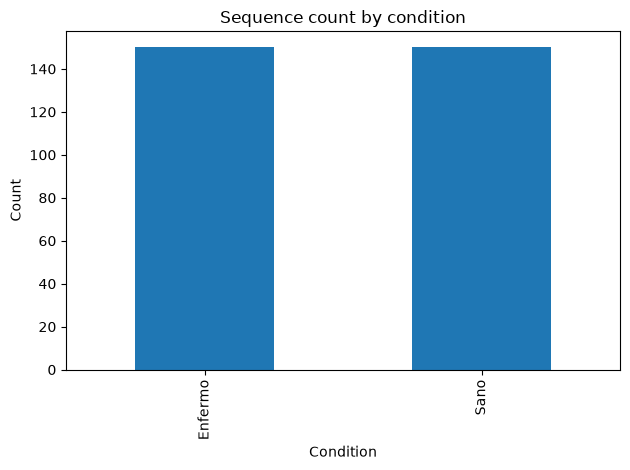

In [18]:
plt.figure(figsize=(5, 4))
label_counts.plot(kind="bar", x="condition_es", y="count", legend=False)
plt.title("Sequence count by condition")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bridge_04_uniprot300_label_distribution.png", dpi=150)
plt.show()

## 13. Descriptor summaries by label

This is a simple but powerful EDA step.

We calculate mean and standard deviation for each descriptor by condition.

In [19]:
summary_by_label = (
    eda_df
    .groupby("condition_es")[descriptor_cols]
    .agg(["mean", "std", "median"])
)

summary_by_label.head()

modlamp_global_Length                    modlamp_global_MW                          modlamp_global_Charge                    \
                              mean         std median              mean           std     median                  mean        std median   
condition_es                                                                                                                               
Enfermo                 704.726667  579.520363  537.5        78237.0836  64212.291887  59832.820              0.763593  17.117008  1.584   
Sano                    461.380000  395.013663  359.0        51521.1038  43669.856919  41761.315            -10.625960  21.431412 -5.251   

             modlamp_global_ChargeDensity                     modlamp_global_pI                     modlamp_global_InstabilityInd                        \
                                     mean       std    median              mean       std    median                          mean        std     median   
condition_es                                                                                                                                              
Enfermo                          0.000068  0.000255  0.000030          7.767244  1.472549  7.749207                     52.155143  13.336916  50.095624   
Sano                            -0.000129  0.000381 -0.000139          6.646441  1.903139  6.105713                     45.132896  11.076314  43.663889   

             modlamp_global_Aromaticity                     modlamp_global_AliphaticInd                       modlamp_global_BomanInd                      \
                                   mean       std    median                        mean        std     median                    mean       std    median   
condition_es                                                                                                                                                
Enfermo                        0.080745  0.033017  0.076680                   83.246754  17.913986  82.438890                1.577071  0.757972  1.698381   
Sano                           0.082225  0.030450  0.082021                   75.523402  16.112144  77.244366                1.861952  0.593009  1.819584   

             modlamp_global_HydrophRatio                     modlamp_scale_eisenberg_global                     modlamp_scale_kytedoolittle_global            \
                                    mean       std    median                           mean       std    median                               mean       std   
condition_es                                                                                                                                                   
Enfermo                         0.372227  0.068016  0.364510                       0.018364  0.145607 -0.002240                           0.084335  0.147040   
Sano                            0.342249  0.052482  0.347649                      -0.036071  0.112840 -0.029215                           0.012078  0.113626   

                       modlamp_scale_hoppwoods_global                     modlamp_moment_eisenberg                     modlamp_moment_kytedoolittle            \
                median                           mean       std    median                     mean       std    median                         mean       std   
condition_es                                                                                                                                                    
Enfermo       0.059986                       0.012286  0.276111  0.061549                 0.763106  0.103143  0.767387                     0.708074  0.083812   
Sano          0.029470                       0.130166  0.255134  0.097609                 0.742364  0.090521  0.741494                     0.694607  0.073595   

                       modlamp_profile_eisenberg_profile_mean                     modlamp_profile_eisenberg_profile_std                      \


In [20]:
# Flatten multi-level columns for CSV export.
summary_by_label_export = summary_by_label.copy()
summary_by_label_export.columns = ["_".join(col).strip() for col in summary_by_label_export.columns.values]
summary_by_label_export = summary_by_label_export.reset_index()
summary_by_label_export.to_csv(SUMMARY_BY_LABEL_CSV, index=False)
SUMMARY_BY_LABEL_CSV

PosixPath('../outputs/uniprot300_modlamp_summary_by_label.csv')

## 14. Simple descriptor visualizations

We use a few boxplots to compare descriptor distributions between `Sano` and `Enfermo`.

These plots are not statistical tests. They are visual summaries used to understand the dataset.

In [21]:
selected_descriptors = [
    "modlamp_global_Length",
    "modlamp_global_MW",
    "modlamp_global_Charge",
    "modlamp_global_pI",
    "modlamp_global_InstabilityInd",
    "modlamp_global_HydrophRatio",
    "modlamp_scale_eisenberg_global",
    "modlamp_moment_eisenberg",
]

selected_descriptors = [col for col in selected_descriptors if col in eda_df.columns]
selected_descriptors

['modlamp_global_Length',
 'modlamp_global_MW',
 'modlamp_global_Charge',
 'modlamp_global_pI',
 'modlamp_global_InstabilityInd',
 'modlamp_global_HydrophRatio',
 'modlamp_scale_eisenberg_global',
 'modlamp_moment_eisenberg']

<Figure size 500x400 with 0 Axes>

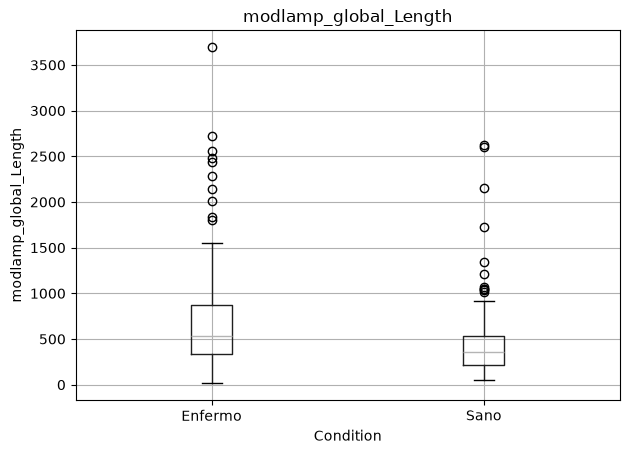

<Figure size 500x400 with 0 Axes>

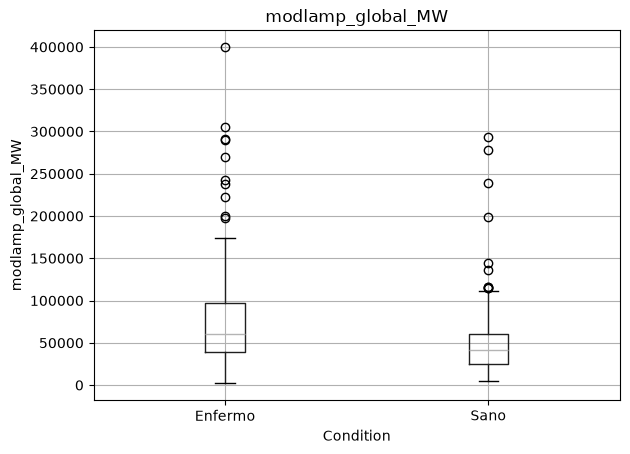

<Figure size 500x400 with 0 Axes>

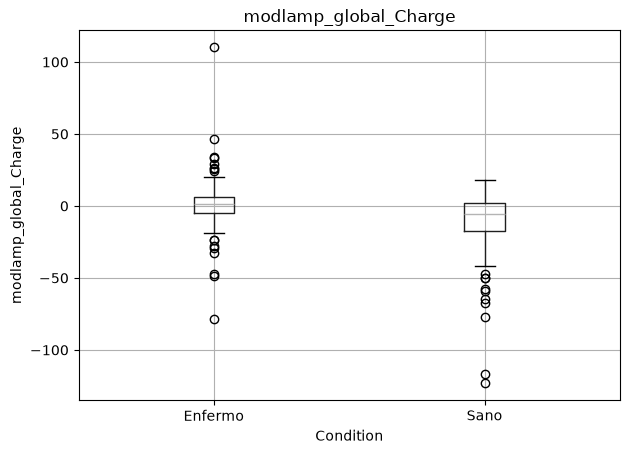

<Figure size 500x400 with 0 Axes>

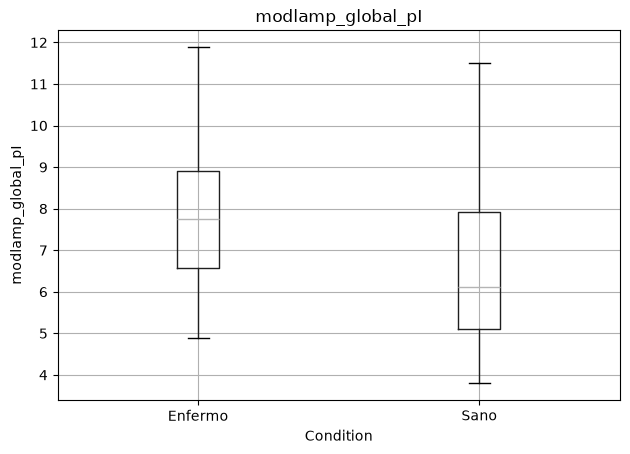

<Figure size 500x400 with 0 Axes>

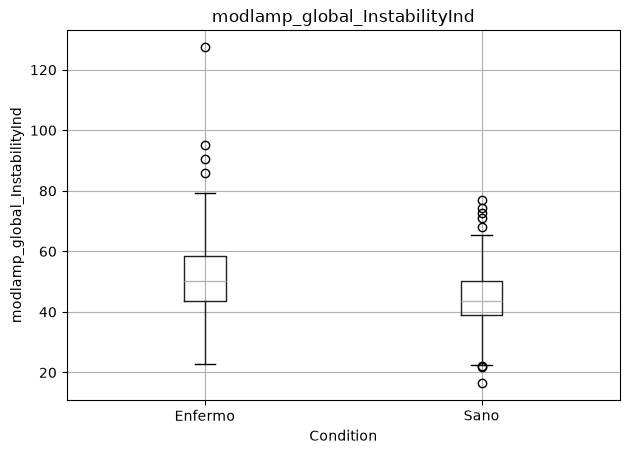

<Figure size 500x400 with 0 Axes>

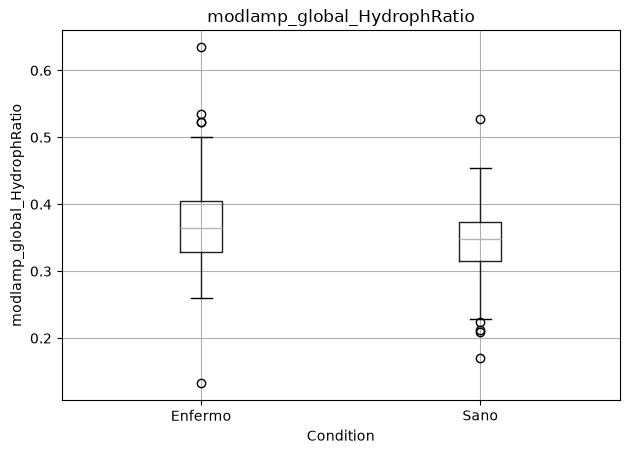

<Figure size 500x400 with 0 Axes>

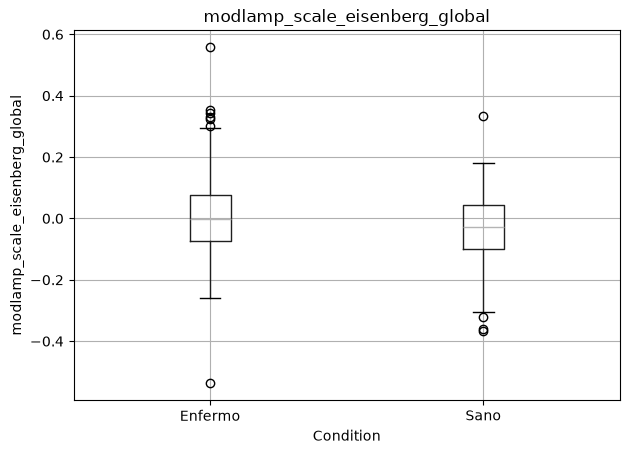

<Figure size 500x400 with 0 Axes>

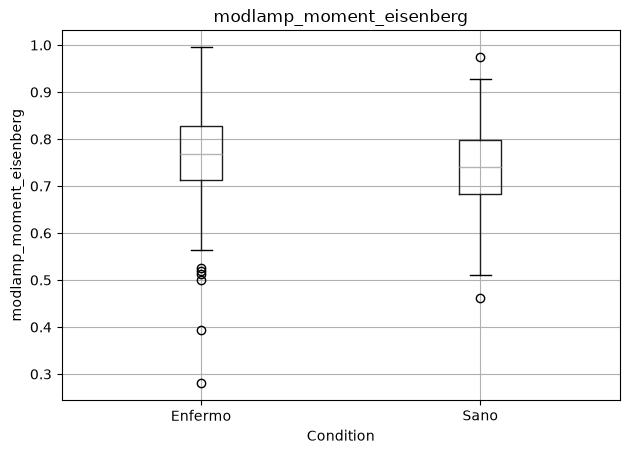

In [22]:
for col in selected_descriptors:
    plt.figure(figsize=(5, 4))
    eda_df.boxplot(column=col, by="condition_es")
    plt.title(col)
    plt.suptitle("")
    plt.xlabel("Condition")
    plt.ylabel(col)
    plt.tight_layout()
    safe_name = col.replace("/", "_").replace(" ", "_")
    plt.savefig(FIGURE_DIR / f"bridge_04_uniprot300_boxplot_{safe_name}.png", dpi=150)
    plt.show()

## 15. Correlation matrix

A correlation matrix helps identify descriptors that behave similarly.

For example, molecular weight and length are usually highly correlated because longer proteins tend to have larger molecular weight.

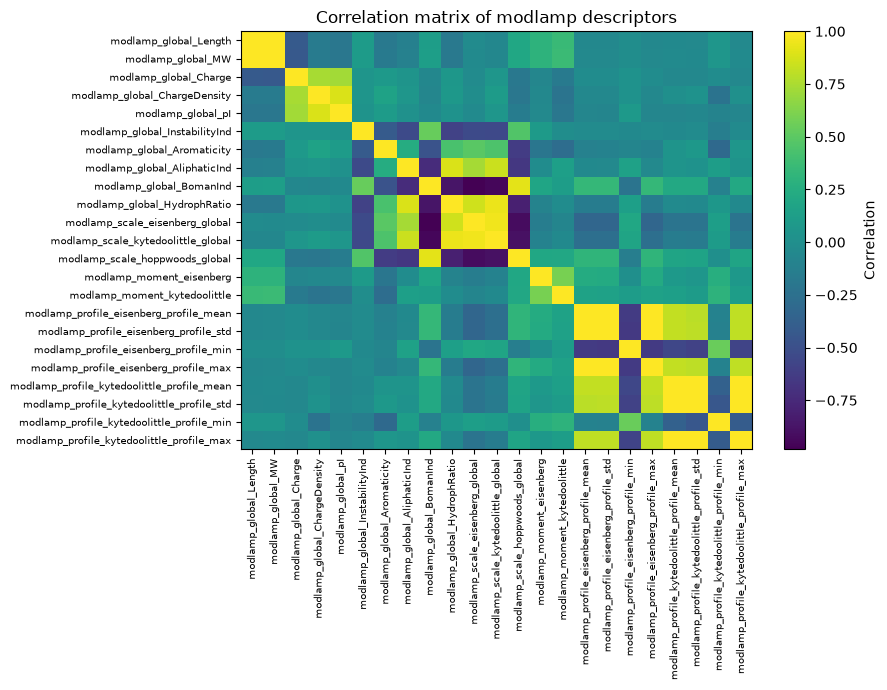

In [23]:
corr = eda_df[descriptor_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
plt.title("Correlation matrix of modlamp descriptors")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bridge_04_uniprot300_descriptor_correlation_matrix.png", dpi=150)
plt.show()

## 16. PCA of modlamp descriptors

PCA requires a numerical feature matrix.

Before PCA, we:

1. select descriptor columns
2. impute missing values
3. standardize features
4. fit PCA
5. plot PC1 vs PC2

Standardization is important because descriptors are measured on different scales.

In [24]:
X = eda_df[descriptor_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
pca = PCA(n_components=2, random_state=RANDOM_SEED)

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "sequence_id": eda_df["sequence_id"].values,
    "organism": eda_df["organism"].values,
    "condition_en": eda_df["condition_en"].values,
    "condition_es": eda_df["condition_es"].values,
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
})

explained = pca.explained_variance_ratio_
print(f"PC1 explained variance: {explained[0]:.3f}")
print(f"PC2 explained variance: {explained[1]:.3f}")
print(f"Total explained variance: {explained.sum():.3f}")

pca_df.head()

PC1 explained variance: 0.315
PC2 explained variance: 0.219
Total explained variance: 0.535


,sequence_id,organism,condition_en,condition_es,PC1,PC2
0,A0A0C5B5G6,Homo sapiens (Human),Diseased,Enfermo,6.086084,7.164858
1,A0A1B0GTW7,Homo sapiens (Human),Diseased,Enfermo,-1.002081,0.640204
2,A0JNW5,Homo sapiens (Human),Diseased,Enfermo,0.961061,-0.683628
3,A0JP26,Homo sapiens (Human),Healthy,Sano,1.225444,-1.879151
4,A0PK11,Homo sapiens (Human),Diseased,Enfermo,-3.655723,5.566599


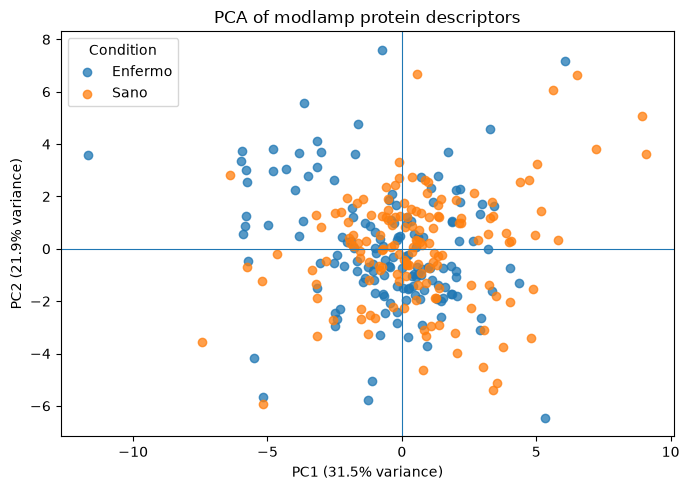

In [25]:
plt.figure(figsize=(7, 5))
for condition, group_df in pca_df.groupby("condition_es"):
    plt.scatter(group_df["PC1"], group_df["PC2"], label=condition, alpha=0.75)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
plt.title("PCA of modlamp protein descriptors")
plt.legend(title="Condition")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bridge_04_uniprot300_pca_modlamp_descriptors.png", dpi=150)
plt.show()

## 17. PCA loadings

PCA loadings indicate how strongly each original descriptor contributes to each principal component.

This helps interpret the PCA plot.

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=descriptor_cols,
    columns=["PC1_loading", "PC2_loading"]
).reset_index().rename(columns={"index": "descriptor"})

loadings["abs_PC1_loading"] = loadings["PC1_loading"].abs()
loadings["abs_PC2_loading"] = loadings["PC2_loading"].abs()

loadings.sort_values("abs_PC1_loading", ascending=False).head(10)

,descriptor,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
8,modlamp_global_BomanInd,0.302184,-0.221515,0.302184,0.221515
10,modlamp_scale_eisenberg_global,-0.297072,0.215995,0.297072,0.215995
12,modlamp_scale_hoppwoods_global,0.287493,-0.236106,0.287493,0.236106
16,modlamp_profile_eisenberg_profile_std,0.285388,0.243769,0.285388,0.243769
11,modlamp_scale_kytedoolittle_global,-0.285180,0.250100,0.285180,0.250100
18,modlamp_profile_eisenberg_profile_max,0.285063,0.243240,0.285063,0.243240
15,modlamp_profile_eisenberg_profile_mean,0.284701,0.242674,0.284701,0.242674
19,modlamp_profile_kytedoolittle_profile_mean,0.253531,0.293933,0.253531,0.293933
22,modlamp_profile_kytedoolittle_profile_max,0.253180,0.294405,0.253180,0.294405
20,modlamp_profile_kytedoolittle_profile_std,0.252334,0.294267,0.252334,0.294267


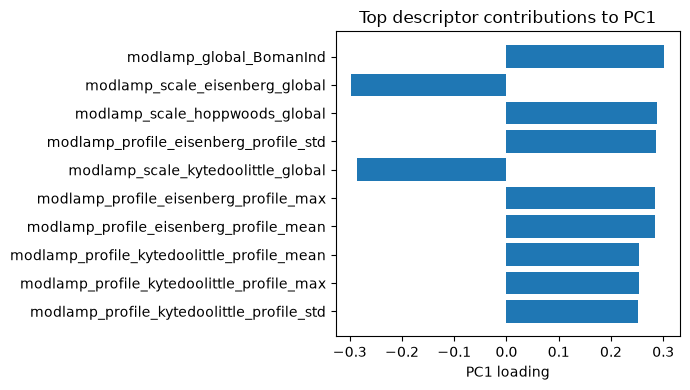

In [27]:
top_pc1 = loadings.sort_values("abs_PC1_loading", ascending=False).head(10)

plt.figure(figsize=(7, 4))
plt.barh(top_pc1["descriptor"], top_pc1["PC1_loading"])
plt.gca().invert_yaxis()
plt.xlabel("PC1 loading")
plt.title("Top descriptor contributions to PC1")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bridge_04_uniprot300_top_pc1_loadings.png", dpi=150)
plt.show()

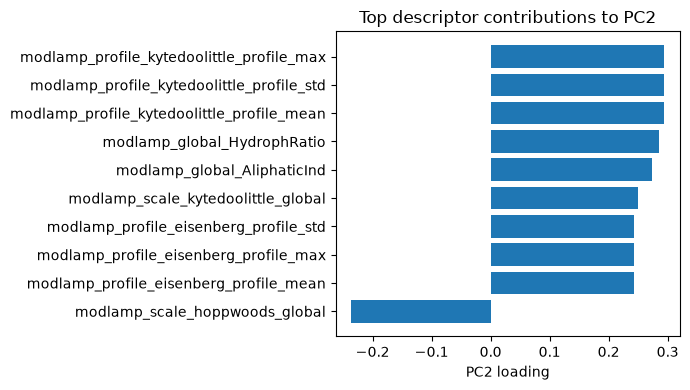

In [28]:
top_pc2 = loadings.sort_values("abs_PC2_loading", ascending=False).head(10)

plt.figure(figsize=(7, 4))
plt.barh(top_pc2["descriptor"], top_pc2["PC2_loading"])
plt.gca().invert_yaxis()
plt.xlabel("PC2 loading")
plt.title("Top descriptor contributions to PC2")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bridge_04_uniprot300_top_pc2_loadings.png", dpi=150)
plt.show()

## 18. Export EDA-ready files

We export four files:

```text
outputs/uniprot300_modlamp_features_with_labels.csv
outputs/uniprot300_modlamp_descriptor_matrix.csv
outputs/uniprot300_modlamp_pca_coordinates.csv
outputs/uniprot300_modlamp_pca_loadings.csv
```

These can be used as input for later notebooks focused on deeper EDA, clustering or machine learning.

In [29]:
eda_df.to_csv(FEATURES_WITH_LABELS_CSV, index=False)
eda_df[["sequence_id"] + descriptor_cols].to_csv(DESCRIPTOR_MATRIX_CSV, index=False)
pca_df.to_csv(PCA_COORDINATES_CSV, index=False)
loadings.to_csv(PCA_LOADINGS_CSV, index=False)

print("Saved:")
print("-", FEATURES_WITH_LABELS_CSV)
print("-", DESCRIPTOR_MATRIX_CSV)
print("-", PCA_COORDINATES_CSV)
print("-", PCA_LOADINGS_CSV)
print("-", SUMMARY_BY_LABEL_CSV)

Saved:
- ../outputs/uniprot300_modlamp_features_with_labels.csv
- ../outputs/uniprot300_modlamp_descriptor_matrix.csv
- ../outputs/uniprot300_modlamp_pca_coordinates.csv
- ../outputs/uniprot300_modlamp_pca_loadings.csv
- ../outputs/uniprot300_modlamp_summary_by_label.csv


## 19. Final interpretation guide

When interpreting this notebook, remember:

1. The input file is a protein descriptor table generated from UniProt records.
2. The labels may be synthetic unless a real label column was provided.
3. Boxplots show descriptor distributions by group.
4. PCA shows whether the descriptor space has visible structure.
5. PCA separation does not prove biological causality or predictive performance.
6. This notebook prepares the dataset for a future, deeper EDA notebook.

## 20. Student exercises

### Exercise 1

Load the exported file:

```text
outputs/uniprot300_modlamp_features_with_labels.csv
```

How many sequences are labeled as `Sano` and how many as `Enfermo`?

### Exercise 2

Select three modlamp descriptors and compare their mean values by condition.

### Exercise 3

Create a boxplot for `modlamp_global_pI` by condition.

### Exercise 4

Find the five descriptors with the strongest absolute contribution to PC1.

### Exercise 5

Change the synthetic label generation rule and rerun the PCA. Does the visual separation change?